# Валидация и подбор гиперпараметров

## Работа с картинками

Сегодня мы будем работать с датасетом изображений. Так как мы еще не работали с таким форматом данных, сначала разберемся, как это можно сделать.

Существует много способов извлечения признаков из картинок, сегодня мы рассмотрим только некоторые из них.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import cv2
import os
from skimage.feature import hog
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

In [ ]:
# Загружаем картинку
img = cv2.imread("/content/drive/MyDrive/ML_training_data/2024-02-27 01-27-27.jpg")

array([[[ 81,  85,  73],
        [ 81,  85,  73],
        [ 82,  86,  74],
        ...,
        [ 61,  64,  48],
        [ 78,  81,  65],
        [ 88,  91,  75]],

       [[ 81,  85,  73],
        [ 81,  85,  73],
        [ 82,  86,  74],
        ...,
        [ 61,  64,  48],
        [ 80,  83,  67],
        [ 95,  98,  82]],

       [[ 81,  85,  73],
        [ 81,  85,  73],
        [ 82,  86,  74],
        ...,
        [ 75,  76,  60],
        [102, 103,  87],
        [125, 126, 110]],

       ...,

       [[ 38,  31,  16],
        [ 40,  33,  18],
        [ 42,  35,  20],
        ...,
        [ 48,  53,  52],
        [ 49,  54,  53],
        [ 49,  54,  53]],

       [[ 37,  30,  15],
        [ 39,  32,  17],
        [ 41,  34,  19],
        ...,
        [ 49,  54,  53],
        [ 50,  55,  54],
        [ 50,  55,  54]],

       [[ 37,  30,  13],
        [ 39,  32,  15],
        [ 41,  34,  17],
        ...,
        [ 50,  55,  54],
        [ 50,  55,  54],
        [ 51,  56,  55]]], dtype=uint8)
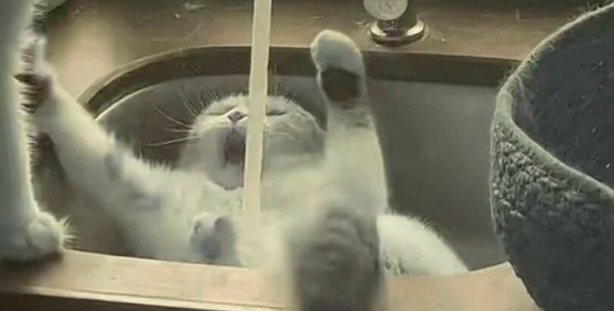

In [ ]:
img

In [ ]:
# Переводим в RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

array([[[ 73,  85,  81],
        [ 73,  85,  81],
        [ 74,  86,  82],
        ...,
        [ 48,  64,  61],
        [ 65,  81,  78],
        [ 75,  91,  88]],

       [[ 73,  85,  81],
        [ 73,  85,  81],
        [ 74,  86,  82],
        ...,
        [ 48,  64,  61],
        [ 67,  83,  80],
        [ 82,  98,  95]],

       [[ 73,  85,  81],
        [ 73,  85,  81],
        [ 74,  86,  82],
        ...,
        [ 60,  76,  75],
        [ 87, 103, 102],
        [110, 126, 125]],

       ...,

       [[ 16,  31,  38],
        [ 18,  33,  40],
        [ 20,  35,  42],
        ...,
        [ 52,  53,  48],
        [ 53,  54,  49],
        [ 53,  54,  49]],

       [[ 15,  30,  37],
        [ 17,  32,  39],
        [ 19,  34,  41],
        ...,
        [ 53,  54,  49],
        [ 54,  55,  50],
        [ 54,  55,  50]],

       [[ 13,  30,  37],
        [ 15,  32,  39],
        [ 17,  34,  41],
        ...,
        [ 54,  55,  50],
        [ 54,  55,  50],
        [ 55,  56,  51]]], dtype=uint8)
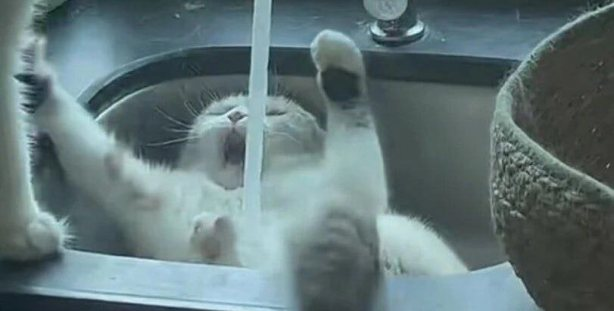

In [ ]:
img

Все картинки должны быть одинакового размера, чтобы с ними можно было работать:

In [ ]:
img_small = cv2.resize(img, (64, 64))

array([[[ 76,  88,  84],
        [ 89, 102,  97],
        [104, 124, 119],
        ...,
        [ 40,  55,  57],
        [ 38,  53,  52],
        [ 45,  61,  60]],

       [[ 76,  88,  84],
        [ 90, 102,  98],
        [110, 130, 125],
        ...,
        [ 62,  80,  80],
        [ 75,  96,  91],
        [125, 145, 144]],

       [[ 77,  89,  85],
        [ 93, 105, 101],
        [120, 140, 135],
        ...,
        [128, 148, 147],
        [118, 139, 133],
        [ 46,  62,  57]],

       ...,

       [[ 23,  36,  44],
        [ 22,  35,  43],
        [ 23,  38,  45],
        ...,
        [ 56,  57,  52],
        [ 51,  52,  47],
        [ 51,  54,  47]],

       [[ 22,  36,  43],
        [ 23,  36,  44],
        [ 24,  37,  45],
        ...,
        [ 58,  59,  54],
        [ 54,  55,  50],
        [ 52,  55,  47]],

       [[ 21,  36,  43],
        [ 20,  35,  42],
        [ 23,  37,  44],
        ...,
        [ 55,  56,  51],
        [ 61,  63,  58],
        [ 54,  55,  50]]], dtype=uint8)
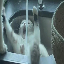

In [ ]:
img_small

По сути картинки представляют из себя трехмерные матрицы, где каждое число отвечает за интенсивность проявления цвета в текущем канале (красном, синем или зеленом). Поэтому мы можем представить наши картинки как numpy array. Тем не менее, для дальнейшей работы нам нужны будут одномерные матрицы, поэтому мы "растянем" трехмерные матрицы в одномерные вектора методом .flatten():

In [ ]:
arr = np.array(img_small)
print(arr.shape)

flat_arr = arr.flatten()
print(flat_arr.shape)

(64, 64, 3)
(12288,)


In [ ]:
64 * 64 * 3

12288

Также мы бы хотели иметь признаки, которые указывают на распределение интенсивности цвета в разных цветовых каналах. Для этого мы сделаем **цветовые гистограммы.**

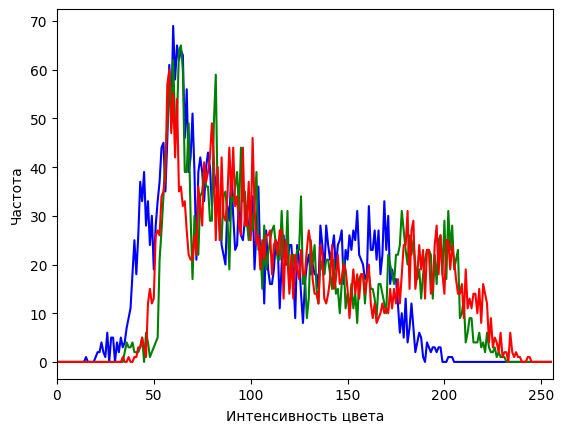

In [ ]:
colors = ('b', 'g', 'r')
color_hists = []
plt.figure()

for i, col in enumerate(colors):
    # Параметры функции calcHist:
    # images: список изображений
    # channels: индекс цветового канала (0 - синий, 1 - зелёный, 2 - красный)
    # mask: маска - numpy-матрица, которая показывает, для какой части изображения делать гистограмму (None - сделать для всего изображения)
    # histSize: количество ячеек гистограммы
    # ranges: диапазон значений пикселей ([0, 256] для восьмибитных картинок)
    hist = cv2.calcHist([img_small], [i], None, [256], [0, 256])
    color_hists.append(hist)
    plt.plot(hist, color=col)
    plt.xlim([0, 256])

plt.xlabel('Интенсивность цвета')
plt.ylabel('Частота')
plt.show()

Наша картинка довольно неяркая, поэтому логично, что интенсивность большинства пикселей находится в районе от 50 до 100.

In [ ]:
# соберём гистограммы в одну матрицу
hist_features = np.concatenate(color_hists).flatten()

In [ ]:
hist_features.shape

(768,)

Также нам хотелось бы иметь информацию о текстуре и формах на изображении. Для этого мы применим **гистограмму ориентированных градиентов (HOG, histogram of oriented gradients).**

Мы бы хотели получить информацию о направлении и величине векторов [цветовых градиентов](https://en.wikipedia.org/wiki/Image_gradient) на изображении:
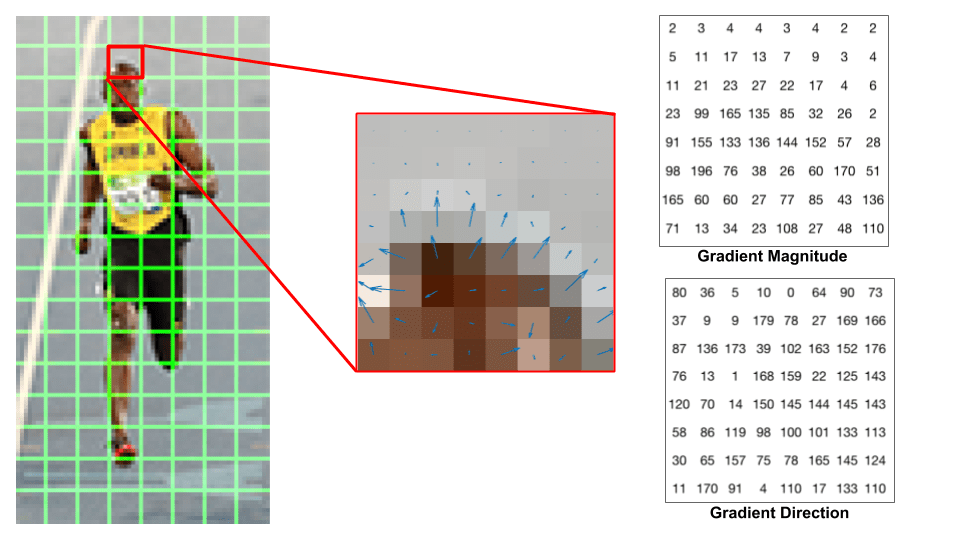
Картинка: https://learnopencv.com/histogram-of-oriented-gradients/

Однако хранить несколько матриц с информацией о каждом пикселе не очень удобно. Можно сжать информацию, создавая гистограммы ориентированных градиентов для каждого кусочка изображения. Таким образом, информация, переданная двумя матрицами на иллюстрации выше, будет сжата до количества ячеек в гистограмме, которое можно задать самостоятельно.

В целом, процесс создания HOG выглядит так:


1.   Вычисляются градиентные изображения: лишняя информация убирается, внимание уделяется направлению и интенсивности линий;
2.   Гистограмма градиентов вычисляется для каждого участка изображения заданного размера;
3.   Гистограммы пересекающихся блоков на изображении нормализуются, нормализованные вектора объединяются в  единый вектор.

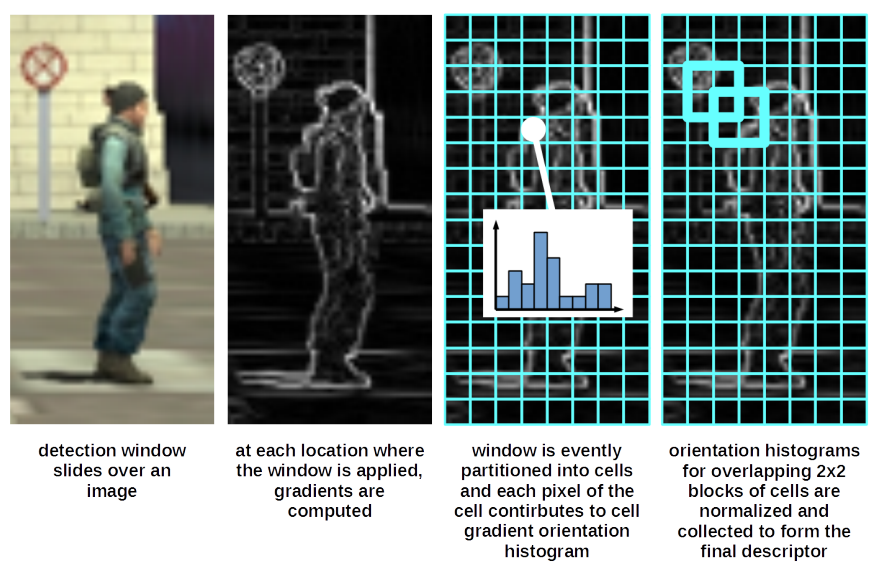

Картинка: Olejniczak, Michał & Kraft, Marek. (2017). Taming the HoG: The Influence of Classifier Choice on Histogram of Oriented Gradients Person Detector Performance. 552-560. 10.1007/978-3-319-59063-9_49.

Результирующий HOG-дескриптор можно представить примерно в таком виде:

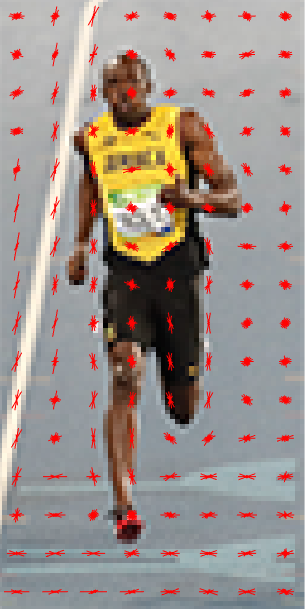

In [ ]:
# убираем лишнюю информацию (цвет)
from skimage.color import rgb2gray
gray = rgb2gray(img_small)

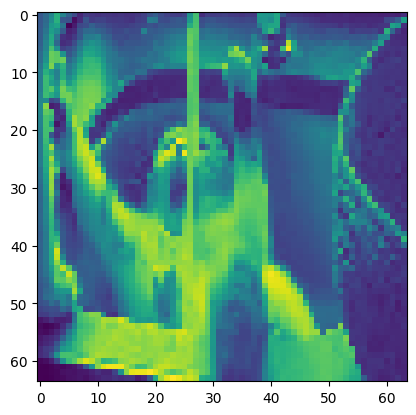

In [ ]:
plt.imshow(gray)

In [ ]:
hog_features, hog_image = hog(
                              gray,
                              # количество ячеек гистограммы
                              orientations=8,
                              # размер каждой клетки, на которые делится изображение
                              pixels_per_cell=(8, 8),
                              # сколько клеток объединять для нормализации
                              cells_per_block=(2, 2),
                              # метод нормализации
                              block_norm='L2-Hys',
                              # нужна ли визуализация
                              visualize=True
                          )

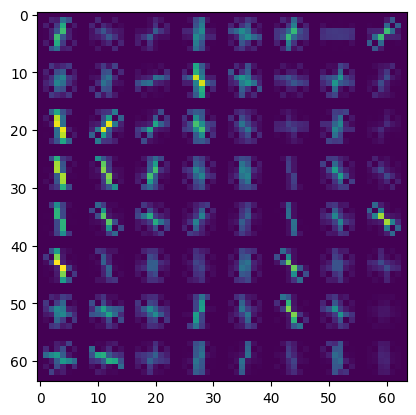

In [ ]:
plt.imshow(hog_image)

In [ ]:
result = np.concatenate([flat_arr, hist_features, hog_features])

## Обработка данных

Теперь сделаем функцию для работы со всеми картинками. Мы будем читать картинки прямо из архива, не извлекая их на диск.

Мы будем классифицировать изображения бабочек из этого датасета: https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification. Мы возьмем только тренировочные изображения, т.к. лейблов для тестового сета на каггле нет. Лейблы попробуем не кодировать, а применять прямо так.

In [ ]:
import io
import zipfile
import pandas as pd

In [ ]:
def load_images_from_archive(arch_path):
  with zipfile.ZipFile(arch_path, 'r') as z:

    with z.open('Training_set.csv') as f:
      train_labels = pd.read_csv(f)

    for n, row in train_labels.iterrows():
      img_name = row['filename']
      label = row['label']
      img_file = z.read(f"train/{img_name}")
      image = cv2.imdecode(np.frombuffer(img_file, np.uint8), cv2.IMREAD_COLOR)
      yield image, label

In [ ]:
def get_features_from_image(img):
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  img_small = cv2.resize(img, (64, 64))
  flat_arr = np.array(img_small).flatten()

  color_hists = []

  for i in list(range(3)):
      hist = cv2.calcHist([img_small], [i], None, [256], [0, 256])
      color_hists.append(hist)

  hist_features = np.concatenate(color_hists).flatten()

  gray = rgb2gray(img_small)

  hog_features = hog(
                      gray,
                      orientations=8,
                      pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2),
                      block_norm='L2-Hys'
                  )

  result = np.concatenate([flat_arr, hist_features, hog_features])

  return result

In [ ]:
def build_feature_matrix(arch_path):
  features = []
  labels = []

  for image, label in load_images_from_archive(arch_path):
    vector = get_features_from_image(image)
    features.append(vector)
    labels.append(label)

  return np.array(features), labels

In [ ]:
X, labels = build_feature_matrix('/content/drive/MyDrive/ML_training_data/butterflies/archive (2).zip')

In [ ]:
X.shape, len(labels)

((6499, 14624), 6499)

Посмотрим, сколько у нас классов и какой между ними баланс:

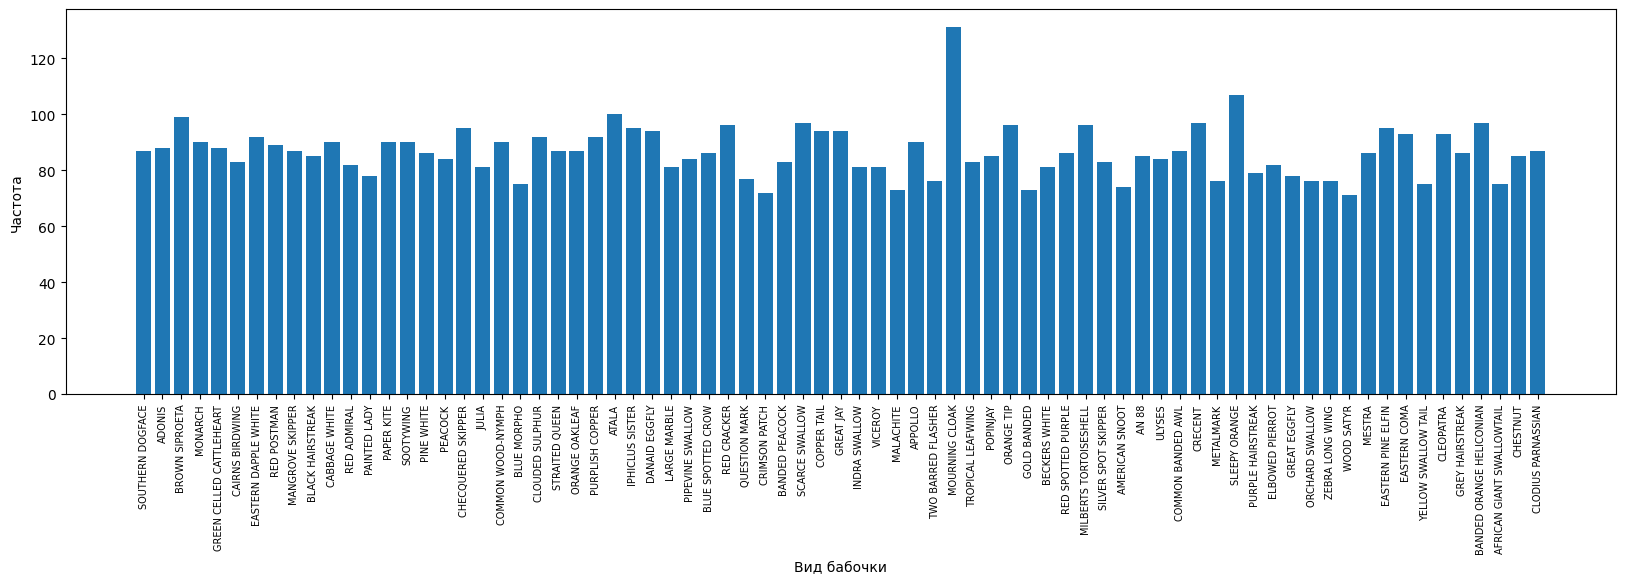

In [ ]:
c = Counter(labels)

types = list(c.keys())
counts = list(c.values())

plt.figure(figsize=(20, 5))
plt.bar(types, counts)
plt.xlabel("Вид бабочки")
plt.ylabel("Частота")
plt.xticks(rotation=90, fontsize=7)
plt.show()

Баланс нормальный, можно делить на тренировочную и тестовую выборки.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, stratify=labels)

In [ ]:
print(len(X_train), len(X_test))

5199 1300


Нормализуем признаки и попробуем уменьшить размерность пространства.

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pca = PCA(n_components=100)
pca.fit(X_train_scaled)
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
# проверим, сколько процентов дисперсии сохранилось
sum(pca.explained_variance_ratio_)

np.float64(0.6575289551698957)

Теперь можно начинать моделировать.

## Подход 1: baseline

Очень популярный подход к классификации изображений - использование HOG-признаков с классификатором, основанным на машине опорных векторов (Support Vector Machine, SVM).

SVM пытается нарисовать разделяющую классы гиперплоскость таким образом, чтобы расстояние между ней и ближайшими точками классов (опорными векторами) было максимальным.

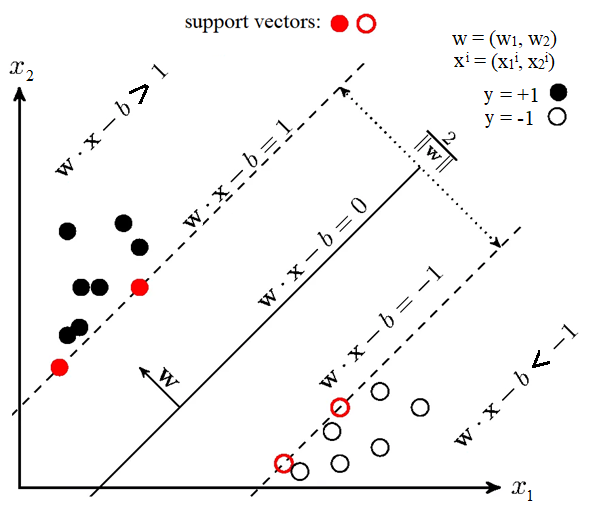

Картинка: https://habr.com/ru/companies/ods/articles/484148/

In [ ]:
# SVC = support vector classification
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [ ]:
svm = LinearSVC(max_iter=5000)

In [ ]:
svm.fit(X_train_pca, y_train)

LinearSVC(max_iter=5000)

In [ ]:
base_preds = svm.predict(X_test_pca)

In [ ]:
print(classification_report(y_test, base_preds))

                           precision    recall  f1-score   support

                   ADONIS       0.68      0.72      0.70        18
AFRICAN GIANT SWALLOWTAIL       0.44      0.53      0.48        15
           AMERICAN SNOOT       0.24      0.27      0.25        15
                    AN 88       0.55      0.65      0.59        17
                  APPOLLO       0.35      0.44      0.39        18
                    ATALA       0.22      0.25      0.23        20
 BANDED ORANGE HELICONIAN       0.44      0.60      0.51        20
           BANDED PEACOCK       0.36      0.29      0.32        17
            BECKERS WHITE       0.09      0.12      0.11        16
         BLACK HAIRSTREAK       0.17      0.24      0.20        17
              BLUE MORPHO       0.40      0.13      0.20        15
        BLUE SPOTTED CROW       0.43      0.35      0.39        17
           BROWN SIPROETA       0.25      0.35      0.29        20
            CABBAGE WHITE       0.45      0.56      0.50     

## Подход 2: кросс-валидация

### cross_validate

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
classifier = LinearSVC(max_iter=5000)

Один из параметров, который принимает на вход функция cross_validate - это словарь, где ключами являются названия метрик, удобные для вас, а значениями - названия этих метрик внутри sklearn. Если вы не знаете, как "достать" нужную вам метрику, обратитесь к функции sklearn.metrics.get_scorer_names().

In [ ]:
scoring = {
           'acc': 'accuracy',
           'f1_score': 'f1_weighted'
           }

Все метрики, которые мы можем выбрать для кросс-валидации, следуют одному и тому же принципу: значение метрики становится больше, когда модель работает лучше. Именно поэтому, например, вместо обычных метрик среднеквадратичной и средней абсолютной ошибки мы взяли бы их обратные версии.

In [ ]:
# https://scikit-learn.org/stable/modules/model_evaluation.html#common-cases-predefined-values
import sklearn
sklearn.metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

In [ ]:
# без return_estimator эта функция не вернёт обученную модель!
scores = cross_validate(classifier,
                        X_train_pca,
                        y_train,
                        scoring=scoring,
                        cv=5,
                        return_estimator=True,
                        return_train_score=True,
                        )

In [ ]:
scores

{'fit_time': array([10.5057435 , 12.25377584, 11.24974895, 10.65636063, 11.25643945]),
 'score_time': array([0.01542974, 0.01554036, 0.04706192, 0.01631927, 0.01578069]),
 'estimator': [LinearSVC(max_iter=5000),
  LinearSVC(max_iter=5000),
  LinearSVC(max_iter=5000),
  LinearSVC(max_iter=5000),
  LinearSVC(max_iter=5000)],
 'test_acc': array([0.33461538, 0.33942308, 0.35480769, 0.34711538, 0.33974976]),
 'train_acc': array([0.69920654, 0.68790575, 0.69511902, 0.68790575, 0.68870192]),
 'test_f1_score': array([0.32517874, 0.323207  , 0.34377933, 0.33559659, 0.32352229]),
 'train_f1_score': array([0.69377814, 0.68071251, 0.68832113, 0.6806876 , 0.68199035])}

In [ ]:
scores_df = pd.DataFrame.from_dict(scores)

Обратите внимание, что названия колонок в датафрейме используют те названия метрик, которые являются ключами в словаре scoring.

In [ ]:
scores_df

,fit_time,score_time,estimator,test_acc,train_acc,test_f1_score,train_f1_score
0,10.505744,0.015430,LinearSVC(max_iter=5000),0.334615,0.699207,0.325179,0.693778
1,12.253776,0.015540,LinearSVC(max_iter=5000),0.339423,0.687906,0.323207,0.680713
2,11.249749,0.047062,LinearSVC(max_iter=5000),0.354808,0.695119,0.343779,0.688321
3,10.656361,0.016319,LinearSVC(max_iter=5000),0.347115,0.687906,0.335597,0.680688
4,11.256439,0.015781,LinearSVC(max_iter=5000),0.339750,0.688702,0.323522,0.681990


Можно узнать, например, среднее значение f1:

In [ ]:
print("%0.2f test f1 with a standard deviation of %0.2f" % (scores['test_f1_score'].mean(), scores['test_f1_score'].std()))

0.33 test f1 with a standard deviation of 0.01


Чтобы вытащить одну из пяти моделей, нужно обратиться к ней по индексу:

In [ ]:
y_pred_cv_3 = scores['estimator'][3].predict(X_test_pca)

Теперь мы можем или пользоваться лучшим эстиматором, или заставлять все модели голосовать, или обучиться снова на всех данных (вернуться к подходу 1).

In [ ]:
print(classification_report(y_test, y_pred_cv_3))

                           precision    recall  f1-score   support

                   ADONIS       0.71      0.67      0.69        18
AFRICAN GIANT SWALLOWTAIL       0.44      0.53      0.48        15
           AMERICAN SNOOT       0.27      0.27      0.27        15
                    AN 88       0.71      0.59      0.65        17
                  APPOLLO       0.39      0.39      0.39        18
                    ATALA       0.26      0.30      0.28        20
 BANDED ORANGE HELICONIAN       0.40      0.40      0.40        20
           BANDED PEACOCK       0.33      0.29      0.31        17
            BECKERS WHITE       0.11      0.12      0.11        16
         BLACK HAIRSTREAK       0.21      0.24      0.22        17
              BLUE MORPHO       0.12      0.07      0.09        15
        BLUE SPOTTED CROW       0.50      0.29      0.37        17
           BROWN SIPROETA       0.24      0.35      0.29        20
            CABBAGE WHITE       0.42      0.61      0.50     

### KFold

Для классификации лучше использовать **StratifiedKFold**: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html, который автоматически стратифицирует выборку по зависимой переменной.

In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits)

KFold возвращает индексы тех рядов, которые сейчас являются тренировочными или тестовыми

In [ ]:
for i, (train_index, test_index) in enumerate(cv.split(X_train, y_train)):
  print(f"Fold {i}:")
  print(f"  Train: index={train_index}")
  print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[ 429  580  607 ... 5196 5197 5198]
  Test:  index=[   0    1    2 ... 1409 1414 1470]
Fold 1:
  Train: index=[   0    1    2 ... 5196 5197 5198]
  Test:  index=[ 429  580  607 ... 2687 2699 2709]
Fold 2:
  Train: index=[   0    1    2 ... 5196 5197 5198]
  Test:  index=[1236 1257 1338 ... 3594 3601 3688]
Fold 3:
  Train: index=[   0    1    2 ... 5196 5197 5198]
  Test:  index=[2388 2461 2479 ... 4551 4554 4559]
Fold 4:
  Train: index=[   0    1    2 ... 4551 4554 4559]
  Test:  index=[3587 3626 3629 ... 5196 5197 5198]


Мы будем пользоваться пайплайном, чтобы не инициализировать на каждом фолде и препроцессоры, и модель. Пайплайн позволяет объединить этапы предобработки и моделирования и хранит объекты классов для препроцессинга (например, векторайзеры) и классов моделей в одном месте.

In [ ]:
from sklearn.pipeline import Pipeline

Далее мы итеративно обучаем модель на всех фолдах. Для экономии места на экране будем выводить только общую взвешенную f1-меру.

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
pipes = []

for i, (train_indexes, test_indexes) in enumerate(cv.split(X_train, y_train)):

    print('Fold number: ', i)

    pipe = Pipeline([('scaler', StandardScaler()),
                     ('pca', PCA(n_components=100)),
                     ('svm', LinearSVC(max_iter=5000))])

    current_X_train = X_train[train_indexes]
    current_y_train = np.array(y_train)[train_indexes]
    current_X_test = X_train[test_indexes]
    current_y_test = np.array(y_train)[test_indexes]

    pipe.fit(current_X_train, current_y_train)
    current_preds = pipe.predict(current_X_test)

    print(f1_score(current_y_test, current_preds, average='weighted'))

    pipes.append(pipe)

Fold number:  0
0.33735598905017894
Fold number:  1
0.3306862642308125
Fold number:  2
0.34785792720469455
Fold number:  3
0.3242271468732265
Fold number:  4
0.33160708362164887


In [ ]:
y_test_pred_skf = pipes[3].predict(X_test)

In [ ]:
print(classification_report(y_test, y_test_pred_skf))

                           precision    recall  f1-score   support

                   ADONIS       0.61      0.61      0.61        18
AFRICAN GIANT SWALLOWTAIL       0.35      0.47      0.40        15
           AMERICAN SNOOT       0.23      0.20      0.21        15
                    AN 88       0.64      0.53      0.58        17
                  APPOLLO       0.32      0.33      0.32        18
                    ATALA       0.24      0.30      0.27        20
 BANDED ORANGE HELICONIAN       0.43      0.45      0.44        20
           BANDED PEACOCK       0.33      0.35      0.34        17
            BECKERS WHITE       0.14      0.19      0.16        16
         BLACK HAIRSTREAK       0.15      0.18      0.16        17
              BLUE MORPHO       0.18      0.13      0.15        15
        BLUE SPOTTED CROW       0.27      0.24      0.25        17
           BROWN SIPROETA       0.29      0.40      0.33        20
            CABBAGE WHITE       0.39      0.50      0.44     

## Подход 3: подбор гиперпараметров

In [ ]:
# можно заметить, что здесь уже есть кросс-валидация (CV)
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {'svm__C': [0.5, 1], 'svm__fit_intercept': [True, False]}

In [ ]:
pipe_gs = Pipeline([('scaler', StandardScaler()),
                  ('pca', PCA(n_components=100)),
                  ('svm', LinearSVC(max_iter=5000))])

In [ ]:
search = GridSearchCV(pipe_gs,
                      param_grid,
                      n_jobs=-1,
                      cv=5,
                      scoring='f1_weighted',
                      return_train_score=True,
                      verbose=10)

**Вопрос:** сколько раз будет сделана регрессия (сколько раз пройдет фит)?

In [ ]:
%%time
search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
CPU times: user 43.1 s, sys: 1.7 s, total: 44.8 s
Wall time: 7min 16s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=100)),
                                       ('svm', LinearSVC(max_iter=5000))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.5, 1],
                         'svm__fit_intercept': [True, False]},
             return_train_score=True, scoring='f1_weighted', verbose=10)

In [ ]:
search.cv_results_

{'mean_fit_time': array([38.5013124 , 35.63540368, 41.07942033, 34.67968507]),
 'std_fit_time': array([0.51983155, 1.74772062, 2.18487888, 1.57559003]),
 'mean_score_time': array([0.66180243, 0.46551027, 0.47477913, 0.42561283]),
 'std_score_time': array([0.08843999, 0.14233434, 0.07290237, 0.14474748]),
 'param_svm__C': masked_array(data=[0.5, 0.5, 1.0, 1.0],
              mask=[False, False, False, False],
        fill_value=1e+20),
 'param_svm__fit_intercept': masked_array(data=[True, False, True, False],
              mask=[False, False, False, False],
        fill_value=True),
 'params': [{'svm__C': 0.5, 'svm__fit_intercept': True},
  {'svm__C': 0.5, 'svm__fit_intercept': False},
  {'svm__C': 1, 'svm__fit_intercept': True},
  {'svm__C': 1, 'svm__fit_intercept': False}],
 'split0_test_score': array([0.33977768, 0.28802554, 0.32202773, 0.28680144]),
 'split1_test_score': array([0.33764493, 0.28962551, 0.33012562, 0.29170136]),
 'split2_test_score': array([0.35342618, 0.2980095 , 0.3

In [ ]:
gs_results_df = pd.DataFrame(search.cv_results_)

In [ ]:
gs_results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_svm__C,param_svm__fit_intercept,params,split0_test_score,split1_test_score,split2_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,38.501312,0.519832,0.661802,0.088440,0.5,True,"{'svm__C': 0.5, 'svm__fit_intercept': True}",0.339778,0.337645,0.353426,...,0.341990,0.005869,1,0.690604,0.679570,0.682662,0.673857,0.684529,0.682244,0.005527
1,35.635404,1.747721,0.465510,0.142334,0.5,False,"{'svm__C': 0.5, 'svm__fit_intercept': False}",0.288026,0.289626,0.298010,...,0.293513,0.005109,4,0.458392,0.454614,0.443561,0.456591,0.458380,0.454308,0.005551
2,41.079420,2.184879,0.474779,0.072902,1.0,True,"{'svm__C': 1, 'svm__fit_intercept': True}",0.322028,0.330126,0.345349,...,0.334256,0.008731,2,0.692854,0.685758,0.688348,0.677688,0.687501,0.686430,0.004959
3,34.679685,1.575590,0.425613,0.144747,1.0,False,"{'svm__C': 1, 'svm__fit_intercept': False}",0.286801,0.291701,0.303281,...,0.294383,0.006996,3,0.459169,0.458846,0.450734,0.454070,0.458540,0.456272,0.003337


In [ ]:
gs_preds = search.predict(X_test)

In [ ]:
print(classification_report(y_test, gs_preds))

                           precision    recall  f1-score   support

                   ADONIS       0.68      0.72      0.70        18
AFRICAN GIANT SWALLOWTAIL       0.57      0.53      0.55        15
           AMERICAN SNOOT       0.28      0.33      0.30        15
                    AN 88       0.50      0.59      0.54        17
                  APPOLLO       0.40      0.56      0.47        18
                    ATALA       0.24      0.30      0.27        20
 BANDED ORANGE HELICONIAN       0.42      0.50      0.45        20
           BANDED PEACOCK       0.43      0.35      0.39        17
            BECKERS WHITE       0.20      0.19      0.19        16
         BLACK HAIRSTREAK       0.14      0.18      0.15        17
              BLUE MORPHO       0.38      0.20      0.26        15
        BLUE SPOTTED CROW       0.29      0.29      0.29        17
           BROWN SIPROETA       0.23      0.35      0.27        20
            CABBAGE WHITE       0.48      0.56      0.51     

Посмотрим на лучшие параметры:

In [ ]:
search.best_params_

{'svm__C': 0.5, 'svm__fit_intercept': True}

# Ансамбли

Попробуем улучшить результаты при помощи ансамблирования.


## Bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier

In [ ]:
model = BaggingClassifier(estimator=LinearSVC(max_iter=5000), n_jobs=-1, n_estimators=10, verbose=1)

In [ ]:
model.fit(X_train_pca, y_train)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  5.0min finished


BaggingClassifier(estimator=LinearSVC(max_iter=5000), n_jobs=-1, verbose=1)

In [ ]:
bag_preds = model.predict(X_test_pca)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished


In [ ]:
print(classification_report(y_test, bag_preds))

                           precision    recall  f1-score   support

                   ADONIS       0.68      0.72      0.70        18
AFRICAN GIANT SWALLOWTAIL       0.56      0.67      0.61        15
           AMERICAN SNOOT       0.12      0.13      0.13        15
                    AN 88       0.50      0.65      0.56        17
                  APPOLLO       0.36      0.44      0.40        18
                    ATALA       0.27      0.35      0.30        20
 BANDED ORANGE HELICONIAN       0.33      0.40      0.36        20
           BANDED PEACOCK       0.46      0.35      0.40        17
            BECKERS WHITE       0.11      0.12      0.11        16
         BLACK HAIRSTREAK       0.12      0.18      0.14        17
              BLUE MORPHO       0.20      0.13      0.16        15
        BLUE SPOTTED CROW       0.43      0.35      0.39        17
           BROWN SIPROETA       0.23      0.35      0.28        20
            CABBAGE WHITE       0.40      0.67      0.50     

## Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100)

In [ ]:
rf.fit(X_train_pca, y_train)

RandomForestClassifier()

In [ ]:
base_rf_preds = rf.predict(X_test_pca)

In [ ]:
print(classification_report(y_test, base_rf_preds))

                           precision    recall  f1-score   support

                   ADONIS       0.64      0.78      0.70        18
AFRICAN GIANT SWALLOWTAIL       0.44      0.53      0.48        15
           AMERICAN SNOOT       0.09      0.07      0.08        15
                    AN 88       0.59      0.59      0.59        17
                  APPOLLO       0.27      0.56      0.36        18
                    ATALA       0.17      0.45      0.25        20
 BANDED ORANGE HELICONIAN       0.29      0.35      0.32        20
           BANDED PEACOCK       0.37      0.41      0.39        17
            BECKERS WHITE       0.06      0.06      0.06        16
         BLACK HAIRSTREAK       0.19      0.35      0.24        17
              BLUE MORPHO       0.33      0.07      0.11        15
        BLUE SPOTTED CROW       0.24      0.24      0.24        17
           BROWN SIPROETA       0.24      0.20      0.22        20
            CABBAGE WHITE       0.37      0.56      0.44     

## Gradient Boosting

In [ ]:
# параметр n_iter_no_change применяется для реализации early stopping: остановиться, когда ошибка не меняется n_iter_no_change шагов
gbr = GradientBoostingClassifier(n_estimators=100, random_state=0, verbose=10, n_iter_no_change=10)

In [ ]:
gbr.fit(X_train_pca, y_train)

      Iter       Train Loss   Remaining Time 
         1           3.5967           38.72m
         2           3.2051           50.69m
         3           2.9242           45.60m
         4           2.7041           43.10m
         5           2.5071           41.14m
         6           2.3232           40.66m
         7           2.1675           39.59m
         8           2.0150           38.55m
         9           1.8858           37.80m
        10           1.7643           37.07m
        11           1.6537           36.48m
        12           1.5535           35.98m
        13           1.4684           35.31m
        14           1.3908           34.78m
        15           1.3038           34.47m
        16           1.2246           33.87m
        17           1.1503           33.37m
        18           1.0837           32.84m
        19           1.0233           32.33m
        20           0.9676           31.86m
        21           0.9049           31.34m
        2

GradientBoostingClassifier(n_iter_no_change=10, random_state=0, verbose=10)

In [ ]:
gbr_preds = gbr.predict(X_test_pca)

In [ ]:
print(classification_report(y_test, gbr_preds))

                           precision    recall  f1-score   support

                   ADONIS       0.75      0.50      0.60        18
AFRICAN GIANT SWALLOWTAIL       0.56      0.33      0.42        15
           AMERICAN SNOOT       0.06      0.07      0.06        15
                    AN 88       0.56      0.29      0.38        17
                  APPOLLO       0.21      0.44      0.29        18
                    ATALA       0.14      0.30      0.19        20
 BANDED ORANGE HELICONIAN       0.25      0.20      0.22        20
           BANDED PEACOCK       0.36      0.24      0.29        17
            BECKERS WHITE       0.00      0.00      0.00        16
         BLACK HAIRSTREAK       0.40      0.35      0.38        17
              BLUE MORPHO       0.00      0.00      0.00        15
        BLUE SPOTTED CROW       0.21      0.18      0.19        17
           BROWN SIPROETA       0.05      0.05      0.05        20
            CABBAGE WHITE       0.31      0.28      0.29     

## Stacking

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
estimators = [ ('svm1', LinearSVC(max_iter=5000)),
              ('svm2', LinearSVC(max_iter=5000)),
               ('svm3', LinearSVC(max_iter=5000))]

In [ ]:
final_estimator = RandomForestClassifier()
reg = StackingClassifier(estimators=estimators, final_estimator=final_estimator, verbose=10)

In [ ]:
reg.fit(X_train_pca, y_train)

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   10.9s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   46.7s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:   58.5s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   11.5s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   48.5s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.0min finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   11.8s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   49.9s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.0min finished


StackingClassifier(estimators=[('svm1', LinearSVC(max_iter=5000)),
                               ('svm2', LinearSVC(max_iter=5000)),
                               ('svm3', LinearSVC(max_iter=5000))],
                   final_estimator=RandomForestClassifier(), verbose=10)

In [ ]:
reg_preds = reg.predict(X_test_pca)

In [ ]:
print(classification_report(y_test, reg_preds))

                           precision    recall  f1-score   support

                   ADONIS       0.88      0.78      0.82        18
AFRICAN GIANT SWALLOWTAIL       0.80      0.53      0.64        15
           AMERICAN SNOOT       0.12      0.13      0.12        15
                    AN 88       0.67      0.59      0.62        17
                  APPOLLO       0.29      0.67      0.41        18
                    ATALA       0.21      0.50      0.29        20
 BANDED ORANGE HELICONIAN       0.39      0.35      0.37        20
           BANDED PEACOCK       0.62      0.29      0.40        17
            BECKERS WHITE       0.18      0.12      0.15        16
         BLACK HAIRSTREAK       0.19      0.29      0.23        17
              BLUE MORPHO       0.75      0.20      0.32        15
        BLUE SPOTTED CROW       0.16      0.18      0.17        17
           BROWN SIPROETA       0.36      0.40      0.38        20
            CABBAGE WHITE       0.56      0.28      0.37     